<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    CNN from Scratch
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">
<b>Notebook Description</b><br>
This notebook presents a comprehensive implementation of a Convolutional Neural Network (CNN) from scratch for the task of image classification on the WikiArt dataset.
</div>

<br>

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    Setup
  </h2>
</div>

In [1]:
import os
import sys

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import keras
from keras import layers

# Auto-reload local modules while editing this notebook
%load_ext autoreload
%autoreload 2
from warnings import filterwarnings
filterwarnings("ignore")

sys.path.append(os.path.abspath('../src'))

from utils import (
    evaluate_model,
    load_config,
    load_datasets,
    plot_learning_curves,
    save_history,
    set_seeds,
    predict_tta
)

# Custom callback to manage GPU memory growth
from GPUGuard import GPUGuard

# Load config (relative to notebooks/)
config = load_config('../config.yml')
    
SEED = config['seed']
set_seeds(SEED)

<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    Model Implementation
  </h2>
</div>

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = config['num_classes']

# All paths relative to notebooks/
train_dir = config['paths']['train_dir']
val_dir = config['paths']['val_dir']
test_dir = config['paths']['test_dir']

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

# prefetch datasets for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['residual_block']['checkpoint'],
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95)
 ]

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


### Model Architecture - CNN from Scratch

The model is a custom residual CNN built entirely from scratch, without any pretrained weights. Raw RGB images are fed at the configured resolution (`IMG_SIZE`), rescaled from `[0, 255]` to `[0, 1]` inside the model graph.

The core building block is a **residual block**: two 3x3 convolutional layers with Batch Normalization and ReLU, plus a skip connection that adds the block's input directly to its output (with a 1×1 projection if the filter count changes). This allows gradients to flow more easily and lets the network learn residual corrections rather than full transformations.

Four residual stages are stacked with progressively increasing filter counts (**32 -> 64 -> 128 -> 256**), each followed by MaxPooling to halve the spatial dimensions - capturing low-level features (edges, textures) in early stages and higher-level patterns (brushstrokes, compositional style) in later ones. L2 regularization (`1e-4`) is applied to all convolutional layers.

After the final stage, **Global Average Pooling** collapses the spatial maps into a single vector. The classifier head then applies `Dense(256)` with ReLU, `Dropout(0.5)`, and a final `Dense(NUM_CLASSES)` with softmax over the 23 artist classes.

In [3]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = layers.Rescaling(1.0 / 255)(inputs)

x = residual_block(x, 32)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 64)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 128)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 256)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cnn_residual_v5")

### Training

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=config['max_epochs'],
    callbacks=callbacks,
)

Epoch 1/100


291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1720 - f1_macro: 0.1241 - loss: 3.0656
Epoch 1: val_loss improved from None to 3.55413, saving model to ../models/residual_block/residual_block_best.keras

Epoch 1: finished saving model to ../models/residual_block/residual_block_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 66s 157ms/step - accuracy: 0.2247 - f1_macro: 0.1688 - loss: 2.8020 - val_accuracy: 0.0470 - val_f1_macro: 0.0151 - val_loss: 3.5541 - learning_rate: 1.0000e-04
Epoch 2/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2929 - f1_macro: 0.2310 - loss: 2.4938
Epoch 2: val_loss improved from 3.55413 to 2.34556, saving model to ../models/residual_block/residual_block_best.keras

Epoch 2: finished saving model to ../models/residual_block/residual_block_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - accuracy: 0.3089 - f1_macro: 0.2495 - loss: 2.4391 - val_accuracy: 0.3465 - val_f1_macro: 0.2488 - val_loss: 2.3456 - learning_rate: 1.0000e-04
Epoch 3/10

In [5]:
test_loss, test_accuracy, test_f1, _ , _ ,_  = predict_tta(model, test_ds)
print(f"TTA Results - Loss: {test_loss:.4f} | Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")

TTA Results - Loss: 1.0010 | Accuracy: 0.4483 | F1: 0.3863


### Learning Curves

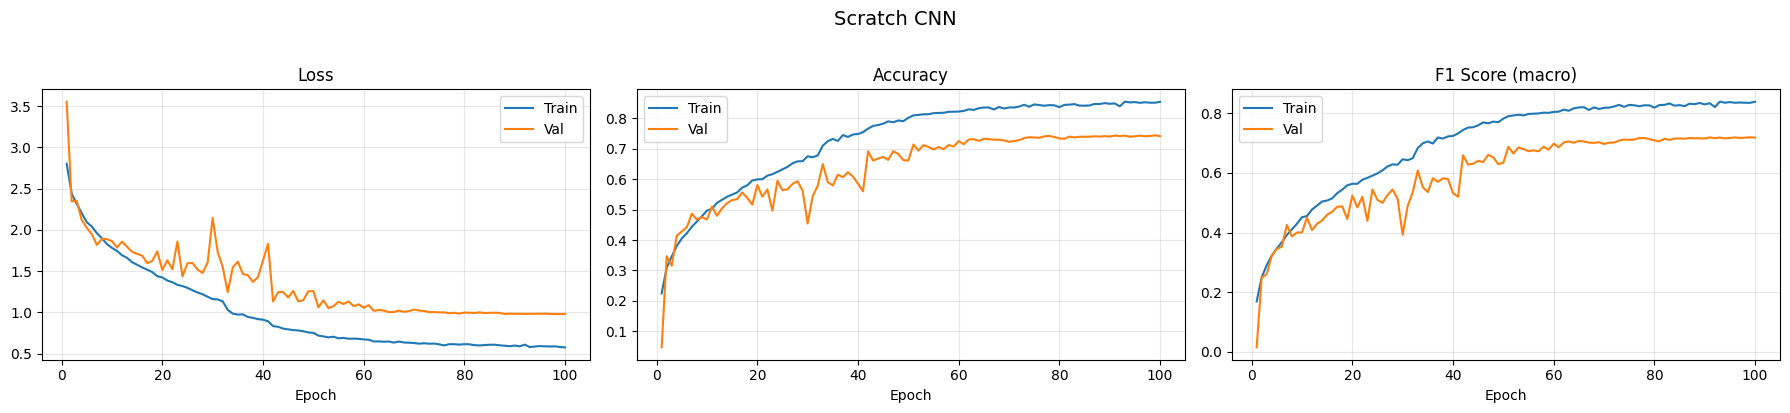

Best epoch (lowest val_loss): 99
  Val Loss: 0.9806
  Val Acc:  0.7439
  Val F1:   0.7188


In [6]:
plot_learning_curves(history, title="Scratch CNN")

### Test Evaluation


  Scratch CNN - Test Evaluation
  Test Loss:     1.0010
  Test Accuracy: 0.7266
  Test F1 Macro: 0.7019

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.83      0.78      0.80        87
      Boris_Kustodiev       0.66      0.52      0.58        67
     Camille_Pissarro       0.67      0.69      0.68        93
        Childe_Hassam       0.71      0.52      0.60        58
         Claude_Monet       0.68      0.77      0.72       141
          Edgar_Degas       0.65      0.63      0.64        65
        Eugene_Boudin       0.64      0.71      0.67        59
         Gustave_Dore       0.95      0.94      0.94        80
           Ilya_Repin       0.56      0.48      0.52        58
      Ivan_Aivazovsky       0.88      0.84      0.86        61
        Ivan_Shishkin       0.70      0.67      0.69        55
  John_Singer_Sargent       0.66      0.76      0.70        83
         Marc_Chagall       0.72      0.72      0.7

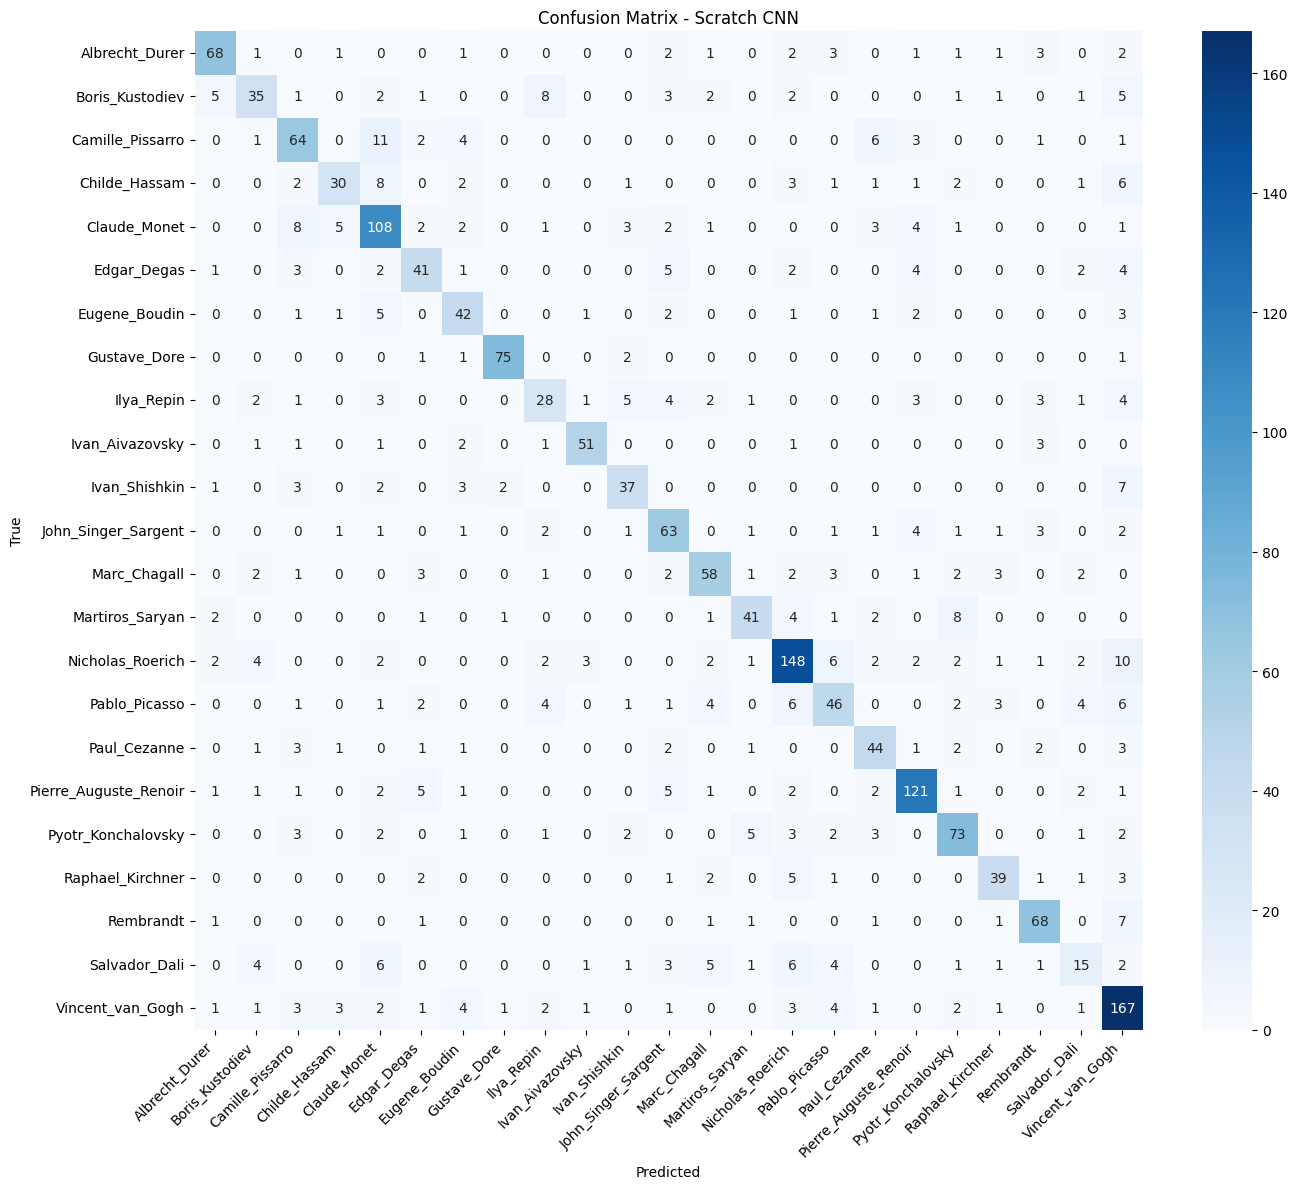

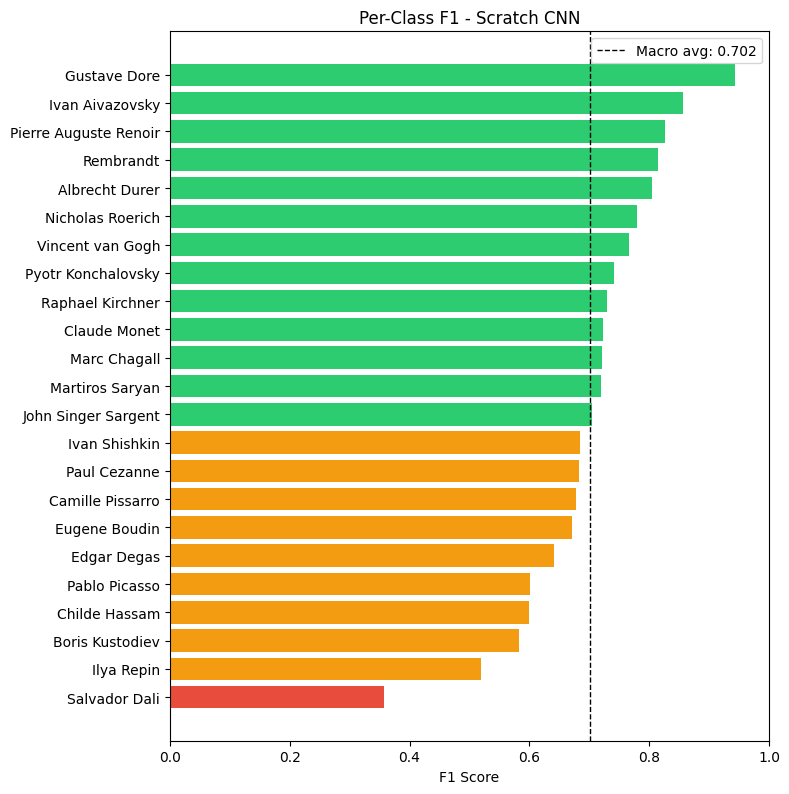

In [7]:
metrics_cnn = evaluate_model(model, test_ds, class_names, "Scratch CNN")

In [8]:
save_history(history, config['models']['residual_block']['history'])

History saved to ../models/residual_block/residual_block_history.json
